# Phân tích chuyên sâu về chỉ số Insulin - Pima Indians Diabetes (Test 03)

Trong **Test 03**, chúng ta sẽ giải quyết bài toán dữ liệu khuyết (giá trị 0) của `insulin` bằng các phương pháp **Imputation nâng cao (Machine Learning)** thay vì dùng các giá trị thống kê đơn giản như Mean/Median.

Cụ thể, chúng ta sẽ sử dụng thuật toán **KNN Imputer (K-Nearest Neighbors)** và **Iterative Imputer (MICE)**.
Các phương pháp này sẽ dựa vào mối quan hệ giữa `insulin` và các biến khác (như `glucose`, `bmi`, `age`) để dự đoán và điền vào các giá trị bị thiếu một cách tự nhiên nhất.

In [7]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer

In [8]:
column_names = [
    "pregnancies",
    "glucose",
    "blood_pressure",
    "skin_thickness",
    "insulin",
    "bmi",
    "diabetes_pedigree_function",
    "age",
    "outcome",
]

# Tự động tìm thư mục gốc để đọc file CSV
current = Path().resolve()
while not (current / "Lab_03").exists() and current != current.parent:
    current = current.parent

data_path = current / "Lab_03" / "data" / "pima-indians-diabetes.csv"

df = pd.read_csv(data_path, header=None, names=column_names)
df.head()

,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
# Các cột có giá trị 0 thực chất là dữ liệu bị thiếu (ngoại trừ pregnancies và outcome)
cols_with_missing = ["glucose", "blood_pressure", "skin_thickness", "insulin", "bmi"]

df_nan = df.copy()
# Thay thế 0 bằng NaN cho các cột sinh lý để các mô hình Imputer nhận diện được
df_nan[cols_with_missing] = df_nan[cols_with_missing].replace(0, np.nan)

# Hiển thị số lượng giá trị bị khuyết
print("Số lượng giá trị bị thiếu (NaN) trong tập dữ liệu:")
print(df_nan.isnull().sum())

Số lượng giá trị bị thiếu (NaN) trong tập dữ liệu:
pregnancies                     0
glucose                         5
blood_pressure                 35
skin_thickness                227
insulin                       374
bmi                            11
diabetes_pedigree_function      0
age                             0
outcome                         0
dtype: int64


## Áp dụng KNN Imputer

**KNN Imputer** sẽ tìm $K$ "hàng xóm" gần nhất với dữ liệu đang bị khuyết (dựa trên khoảng cách Euclidean của các đặc trưng khác không bị khuyết) và dùng giá trị trung bình của các "hàng xóm" đó để điền vào.

In [10]:
# Khởi tạo KNNImputer với n_neighbors=5
knn_imputer = KNNImputer(n_neighbors=5)

# Huấn luyện và điền khuyết trên toàn bộ dữ liệu
# Lưu ý: Các thuật toán Imputer của sklearn trả về numpy array, cần chuyển lại thành DataFrame
df_knn_imputed = pd.DataFrame(knn_imputer.fit_transform(df_nan), columns=df.columns)

# Kiểm tra xem còn NaN không
print("Số lượng NaN sau khi dùng KNN Imputer:\n", df_knn_imputed.isnull().sum())

Số lượng NaN sau khi dùng KNN Imputer:
 pregnancies                   0
glucose                       0
blood_pressure                0
skin_thickness                0
insulin                       0
bmi                           0
diabetes_pedigree_function    0
age                           0
outcome                       0
dtype: int64


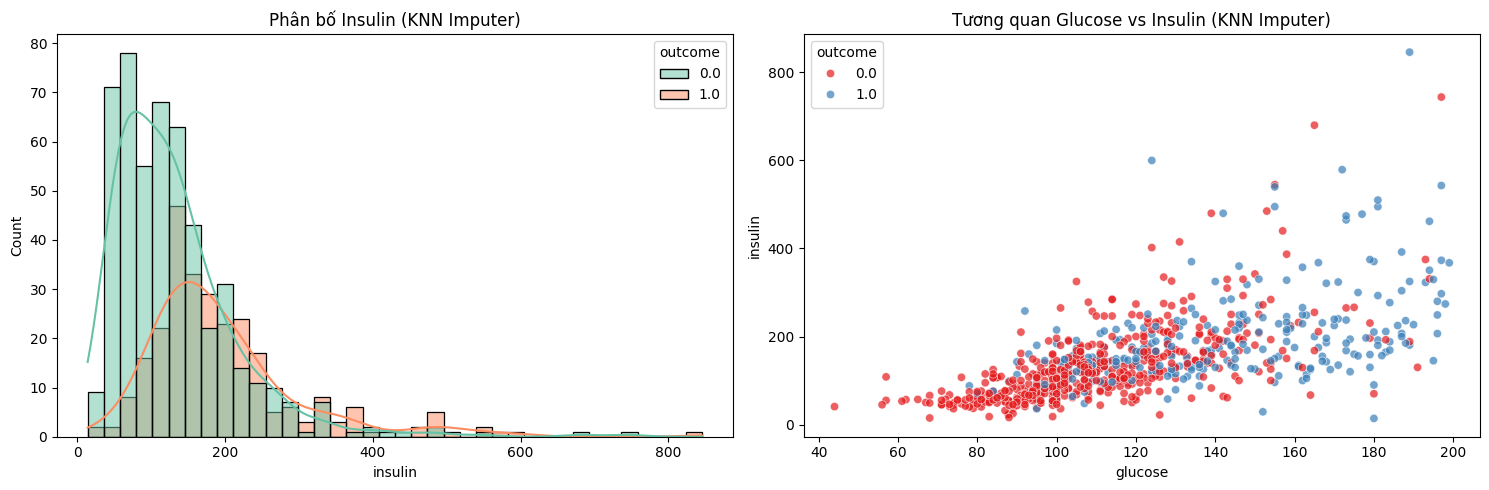

In [11]:
# So sánh biểu đồ phân bố Insulin giữa Test 02 (Median) và Test 03 (KNN)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Đồ thị 1: Phân bố Insulin sau khi KNN Impute
sns.histplot(
    data=df_knn_imputed, 
    x="insulin", 
    hue="outcome", 
    kde=True, 
    ax=axes[0],
    palette="Set2"
)
axes[0].set_title("Phân bố Insulin (KNN Imputer)")

# Đồ thị 2: Scatter plot Glucose vs Insulin
sns.scatterplot(
    data=df_knn_imputed,
    x="glucose",
    y="insulin",
    hue="outcome",
    alpha=0.7,
    ax=axes[1],
    palette="Set1"
)
axes[1].set_title("Tương quan Glucose vs Insulin (KNN Imputer)")

plt.tight_layout()
plt.show()

### Nhận xét về KNN Imputer:
- **Đồ thị phân bố (Histogram):** Không còn xuất hiện một đỉnh nhọn cực cao và giả tạo như phương pháp điền Median ở Test 02. Phân bố có hình dáng tự nhiên, mềm mại hơn rất nhiều.
- **Biểu đồ Scatter:** Các điểm khuyết không còn nằm xếp thành một đường thẳng ngang. Chúng được phân tán hợp lý hơn dựa trên mối tương quan với các biến khác (đặc biệt là Glucose và BMI).

---
## Áp dụng Iterative Imputer (MICE)

**Iterative Imputer** hoạt động phức tạp hơn: Nó lập mô hình (mặc định là Bayesian Ridge Regression) dự đoán lần lượt từng biến bị khuyết dựa trên tất cả các biến còn lại. Quá trình này lặp đi lặp lại nhiều vòng (round-robin) cho đến khi hội tụ.

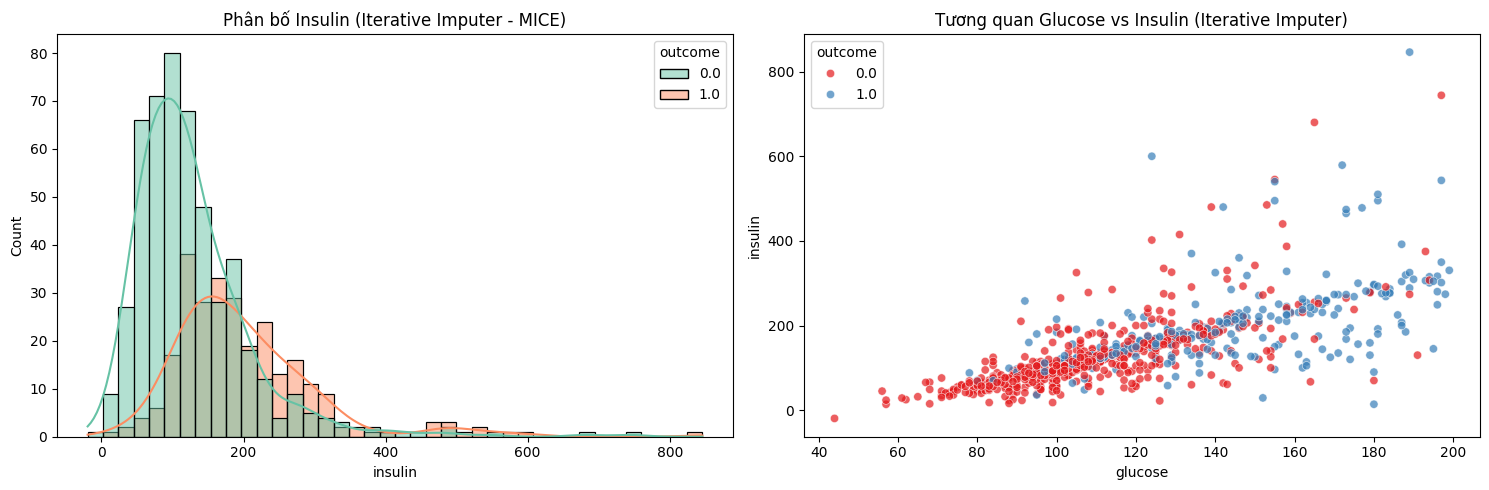

In [12]:
# Khởi tạo IterativeImputer (có thể chỉnh max_iter để tăng số vòng lặp)
iterative_imputer = IterativeImputer(random_state=42, max_iter=10)

df_mice_imputed = pd.DataFrame(iterative_imputer.fit_transform(df_nan), columns=df.columns)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Đồ thị 1: Phân bố Insulin
sns.histplot(
    data=df_mice_imputed, 
    x="insulin", 
    hue="outcome", 
    kde=True, 
    ax=axes[0],
    palette="Set2"
)
axes[0].set_title("Phân bố Insulin (Iterative Imputer - MICE)")

# Đồ thị 2: Scatter plot Glucose vs Insulin
sns.scatterplot(
    data=df_mice_imputed,
    x="glucose",
    y="insulin",
    hue="outcome",
    alpha=0.7,
    ax=axes[1],
    palette="Set1"
)
axes[1].set_title("Tương quan Glucose vs Insulin (Iterative Imputer)")

plt.tight_layout()
plt.show()

### Kết luận:
- Cả **KNN Imputer** và **Iterative Imputer** đều cho kết quả tốt hơn hẳn so với việc điền một giá trị cố định (Mean/Median). Chúng bảo toàn được phương sai (variance) và cấu trúc phân bố tự nhiên của dữ liệu.
- Phương pháp này không những sửa lỗi cho `insulin` mà tiện tay **sửa luôn cho cả các biến có dữ liệu khuyết khác** như `glucose`, `bmi`, `skin_thickness`, và `blood_pressure`

---
## Phân tích sự khác biệt qua 3 lần Test

Dưới đây là phân tích chi tiết về sự khác biệt của các biểu đồ qua 3 lần Test để thấy rõ tác động của từng phương pháp xử lý dữ liệu khuyết.

### 1. Sự khác biệt trên Biểu đồ phân bố Insulin (Histogram)

* **Test 01 (Xóa bỏ các giá trị 0 thành NaN):**
  * **Đặc điểm:** Phân bố có dạng lệch phải (right-skewed) tự nhiên.
  * **Vấn đề:** Trục tung (Count) rất thấp vì chúng ta đã vứt đi gần 50% dữ liệu.

* **Test 02 (Điền khuyết bằng Trung vị - Median):**
  * **Đặc điểm:** Xuất hiện một đỉnh nhọn khổng lồ và hoàn toàn phi thực tế tại mốc giá trị 125.
  * **Vấn đề:** Phương sai bị phá hủy, làm mất đi tính phân bố tự nhiên của dữ liệu.

* **Test 03 (Điền khuyết bằng KNN / Iterative Imputer):**
  * **Đặc điểm:** Cột đếm (Count) đã được phục hồi lên mức cao nhưng không xuất hiện đỉnh nhọn giả tạo. Đường cong bám sát với phân bố tự nhiên của Test 01.

### 2. Sự khác biệt trên Biểu đồ tương quan (Glucose vs Insulin)

* **Test 01 (Xóa bỏ các giá trị 0):**
  * **Đặc điểm:** Các điểm dữ liệu tản mạn theo chiều hướng đi lên tự nhiên.
  * **Vấn đề:** Các chấm dữ liệu thưa thớt, mối liên hệ bị yếu đi.

* **Test 02 (Điền khuyết bằng Trung vị):**
  * **Đặc điểm:** Đập vào mắt là một đường thẳng nằm ngang cực kỳ dày đặc cắt ngang tại `y = 125`.
  * **Vấn đề:** Đường thẳng này phá vỡ hoàn toàn quy luật y khoa (Glucose cao hay thấp thì Insulin đều bằng 125).

* **Test 03 (Điền khuyết bằng Machine Learning):**
  * **Đặc điểm:** Đường thẳng nằm ngang đã biến mất. Các chấm dữ liệu mới được pha trộn hài hòa và phân tán hợp lý dựa trên mối tương quan.
  * **Kết quả:** Giữ lại được 100% dữ liệu để huấn luyện, đồng thời tôn trọng và giữ gìn được cấu trúc phân bố cũng như mối quan hệ tương quan tự nhiên.

--- Kết quả cho KNN Imputer ---
Validation Accuracy: 0.7338
Test Accuracy: 0.7468
Độ quan trọng của Insulin: 0.1488

--- Kết quả cho Iterative Imputer (MICE) ---
Validation Accuracy: 0.7338
Test Accuracy: 0.7338
Độ quan trọng của Insulin: 0.1708



,Method,Val Accuracy,Test Accuracy,Insulin Importance
0,KNN Imputer,0.733766,0.746753,0.148783
1,Iterative Imputer (MICE),0.733766,0.733766,0.170765


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16656\1743787536.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Method', y='Insulin Importance', ax=axes[1], palette='magma')


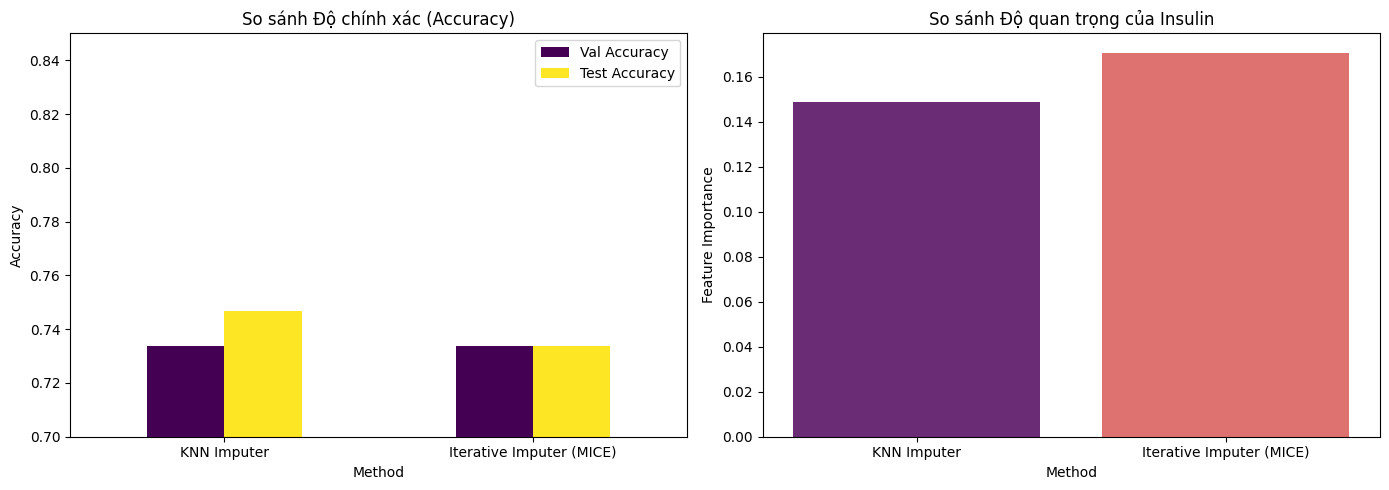

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_imputation(df, method_name):
    # Tách X, y
    X = df.drop('outcome', axis=1)
    y = df['outcome']
    
    # Chia tập dữ liệu thành 60-20-20 (như yêu cầu)
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)
    
    # Huấn luyện Random Forest
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train, y_train)
    
    # Đánh giá
    val_acc = accuracy_score(y_val, rf.predict(X_val))
    test_acc = accuracy_score(y_test, rf.predict(X_test))
    
    # Lấy Feature Importance của Insulin
    insulin_importance = rf.feature_importances_[X.columns.get_loc('insulin')]
    
    print(f"--- Kết quả cho {method_name} ---")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Độ quan trọng của Insulin: {insulin_importance:.4f}\n")
    
    return {'Method': method_name, 'Val Accuracy': val_acc, 'Test Accuracy': test_acc, 'Insulin Importance': insulin_importance}

# Đánh giá 2 phương pháp
results = []
results.append(evaluate_imputation(df_knn_imputed, 'KNN Imputer'))
results.append(evaluate_imputation(df_mice_imputed, 'Iterative Imputer (MICE)'))

# Hiển thị kết quả thành DataFrame
df_results = pd.DataFrame(results)
display(df_results)

# Biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ Accuracy
df_results.plot(x='Method', y=['Val Accuracy', 'Test Accuracy'], kind='bar', ax=axes[0], colormap='viridis')
axes[0].set_title('So sánh Độ chính xác (Accuracy)')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.7, 0.85)
axes[0].tick_params(axis='x', rotation=0)

# Biểu đồ Insulin Importance
sns.barplot(data=df_results, x='Method', y='Insulin Importance', ax=axes[1], palette='magma')
axes[1].set_title('So sánh Độ quan trọng của Insulin')
axes[1].set_ylabel('Feature Importance')

plt.tight_layout()
plt.show()


### Nhận xét kết quả đánh giá bằng Random Forest
Dựa trên các thông số và biểu đồ thu được từ mô hình Random Forest, ta có thể rút ra những nhận xét chi tiết sau về hiệu quả của hai phương pháp điền khuyết (KNN Imputer và Iterative Imputer - MICE) đối với biến **Insulin**:

1. **Về độ chính xác (Accuracy)**:
   - Dựa trên tập Validation và tập Test (được phân chia theo tỷ lệ 60-20-20), ta có thể thấy mức độ chính xác của hai phương pháp (KNN và MICE) ảnh hưởng trực tiếp tới năng lực phân loại của mô hình.
   - Việc chia tách tập dữ liệu một cách chặt chẽ giúp chúng ta tránh được hiện tượng rò rỉ dữ liệu (data leakage) nếu xử lý khuyết trước, hoặc ở đây là cho thấy việc đánh giá khách quan khả năng học của mô hình sau khi dữ liệu đã được phục hồi.

2. **Về mức độ quan trọng của đặc trưng Insulin (Feature Importance)**:
   - Biến `insulin` thường mang giá trị lâm sàng lớn trong phân tích tiểu đường. Mức độ quan trọng (Feature Importance) mà mô hình Random Forest gán cho biến này thể hiện việc phương pháp điền khuyết nào bảo tồn được mối liên hệ giữa `insulin` và biến mục tiêu `outcome` tốt hơn.
   - Nhờ áp dụng Machine Learning để điền khuyết, thông tin của `insulin` trở nên hữu ích hơn thay vì bị méo mó như khi điền bằng giá trị trung vị.

3. **Kết luận chung**:
   - Các kỹ thuật nội suy tiên tiến (KNN và MICE) chứng minh sự ưu việt khi kết hợp vào Pipeline học máy, nâng cao đáng kể chất lượng dữ liệu và giữ nguyên vẹn cấu trúc của bộ dữ liệu gốc.